# Temporal Comparison — Thorax & Trunk Lateral Inclination

Both angles are computed from the **same C3D files** (bilateral recording, no Left/Right split).

| Signal | Source | Formula |
|---|---|---|
| **Thorax Lateral Inclination** | `ThoraxAngles` | `norm(X, Y)` with sign recovered from `trunk_z` |
| **Trunk Extended Lateral Inclination** | `Trunk_Inclination_Angle` | `Z − 90°` (hardware offset correction) |

Edit **only the CONFIGURATION cell**. The rest runs automatically.

In [1]:
# ── Dependencies ───────────────────────────────────────────────────────────────
# If missing: pip install ezc3d numpy scipy matplotlib
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.signal import find_peaks, argrelmin
from scipy.stats import pearsonr, f as f_dist
import ezc3d

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
#  CONFIGURATION  ← edit here
# ══════════════════════════════════════════════════════════════════════════════

# -- Anatomical landmark scenario ----------------------------------------------
# Identifies which anatomical distances were used to build the virtual markers.
# Appears as a prefix in all plot titles.
# Option 1: "(PX -> T8) + (C7 -> T8) Distances"
# Option 2: "(IJ -> T8) + (C7 -> T8) Distances"
# Option 3: "(PX -> T8) + (IJ -> T8) + (C7 -> T8) Distances"
SCENARIO_NAME = "Perfect distances"

# Bilateral movement — one set of 3 recordings (no Left/Right split)
RECORDINGS = [
    {"path": r"C:\Projects\data_organized\grab 7_c3d\sitting\C7\Perfect\Trunk_Inclination_Bi_Cont02.c3d",       "label": "With C7"},
    {"path": r"C:\Projects\data_organized\grab 7_c3d\sitting\NOT_C7\Perfect\Trunk_Inclination_Bi_Cont02.c3d",   "label": "Without C7"},
]

# Sign-recovery threshold: local minima of the Thorax norm below this value
# are treated as zero-crossings (direction changes).
ZERO_THRESHOLD = 15.0   # degrees

# Peak detection parameters (shared between both angle types)
THORAX_PROMINENCE = 5.0   # degrees — small angular range (~20°)
TRUNK_PROMINENCE  = 5.0   # degrees
MIN_DISTANCE      = 30    # frames (at 100 Hz = 0.3 s minimum between peaks)

COLORS     = ["#2E86C1", "#27AE60"]
LINE_WIDTH = 1.5
ALPHA_RAW  = 0.85

OUTPUT_PATH = None
DPI         = 150

In [3]:
# ── Helpers ────────────────────────────────────────────────────────────────────

def read_c3d(filepath):
    """Reads a Vicon Nexus C3D. Returns frame_rate, n_frames, model_outputs dict."""
    filepath = os.path.normpath(os.path.abspath(filepath))
    c = ezc3d.c3d(filepath)
    raw_labels = c["parameters"]["POINT"]["LABELS"]["value"]
    point_data = c["data"]["points"]          # (4, n_labels, n_frames)
    n_labels   = min(len(raw_labels), point_data.shape[1])
    try:
        rate_val   = c["parameters"]["POINT"]["RATE"]["value"]
        frame_rate = int(float(rate_val[0]) if hasattr(rate_val, "__len__") else float(rate_val))
    except (KeyError, IndexError, TypeError, ValueError):
        frame_rate = int(c["header"]["frame_rate"])
    clean_labels = [
        lbl.split(":")[-1].strip() if ":" in lbl else lbl.strip()
        for lbl in raw_labels[:n_labels]
    ]
    model_outputs = {lbl: point_data[:3, i, :].copy() for i, lbl in enumerate(clean_labels)}
    return {"frame_rate": frame_rate, "n_frames": point_data.shape[2], "model_outputs": model_outputs}


def compute_thorax_trunk_pair(c3d_path, zero_threshold=15.0):
    """
    Computes both lateral inclination signals from a single C3D file.

    Thorax Lateral Inclination:
      norm = sqrt(ThoraxAngles[X]^2 + ThoraxAngles[Y]^2)
      Sign recovered segment-by-segment using the median of trunk_z.

    Trunk Extended Lateral Inclination:
      trunk_z = Trunk_Inclination_Angle[Z] - 90.0  (hardware offset correction)

    Returns: (thorax_signed, trunk_z, frame_rate)  — all 1-D float arrays.
    """
    c3d = read_c3d(c3d_path)
    mo  = c3d["model_outputs"]
    fr  = c3d["frame_rate"]

    # Locate variables (case-insensitive, ignore subject prefix already stripped)
    thorax_key = next(
        (k for k in mo if "THORAXANGLES" in k.replace(" ", "_").upper()), None
    )
    trunk_key = next(
        (k for k in mo if "TRUNK_INCLINATION_ANGLE" in k.replace(" ", "_").upper()), None
    )
    if thorax_key is None:
        raise KeyError(f"ThoraxAngles not found in {os.path.basename(c3d_path)}.\nAvailable: {list(mo.keys())}")
    if trunk_key is None:
        raise KeyError(f"Trunk_Inclination_Angle not found in {os.path.basename(c3d_path)}.\nAvailable: {list(mo.keys())}")

    # ── Trunk Extended Lateral Inclination ────────────────────────────────────
    trunk_z = mo[trunk_key][2, :].astype(float) - 90.0

    # ── Thorax Lateral Inclination ────────────────────────────────────────────
    x    = mo[thorax_key][0, :].astype(float)
    y    = mo[thorax_key][1, :].astype(float)
    norm = np.sqrt(x**2 + y**2)

    # Sign recovery: detect local minima of norm close to zero (direction reversals)
    minima_idx  = argrelmin(norm, order=5)[0]
    flip_points = minima_idx[norm[minima_idx] <= zero_threshold]

    n = len(norm)
    sign_arr   = np.ones(n)
    boundaries = np.concatenate([[0], flip_points, [n]]).astype(int)
    for i in range(len(boundaries) - 1):
        start, end = boundaries[i], boundaries[i + 1]
        sign_arr[start:end] = 1.0 if np.median(trunk_z[start:end]) >= 0.0 else -1.0

    thorax_signed = norm * sign_arr
    return thorax_signed, trunk_z, fr


# ── Statistical helpers ────────────────────────────────────────────────────────

def _icc3(a, b):
    """ICC(3,1) two-way fixed, single measures, consistency. Returns (icc, ci_lo, ci_hi)."""
    n, k   = len(a), 2
    data   = np.column_stack([a, b])
    grand  = data.mean()
    r_mean = data.mean(axis=1)
    c_mean = data.mean(axis=0)
    ss_row = k * np.sum((r_mean - grand)**2)
    ss_col = n * np.sum((c_mean - grand)**2)
    ss_err = np.sum((data - grand)**2) - ss_row - ss_col
    ms_row = ss_row / (n - 1)
    ms_err = ss_err / ((n - 1) * (k - 1))
    icc    = (ms_row - ms_err) / (ms_row + (k - 1) * ms_err)
    F      = ms_row / ms_err
    Fc_hi  = f_dist.ppf(0.975, n - 1, (n - 1) * (k - 1))
    Fc_lo  = f_dist.ppf(0.975, (n - 1) * (k - 1), n - 1)
    ci_lo  = np.clip((F / Fc_hi - 1) / (F / Fc_hi + k - 1), -1, 1)
    ci_hi  = np.clip((F * Fc_lo - 1) / (F * Fc_lo + k - 1), -1, 1)
    return float(icc), float(ci_lo), float(ci_hi)


def _stats(diff, sig_a, sig_b):
    """Full metric set with NaN handling (drops frames with marker gaps)."""
    valid       = ~(np.isnan(diff) | np.isnan(sig_a) | np.isnan(sig_b))
    dv, av, bv  = diff[valid], sig_a[valid], sig_b[valid]
    pct         = 100 * valid.mean()
    r, _        = pearsonr(av, bv)
    icc, lo, hi = _icc3(av, bv)
    return {
        "RMSD":      np.sqrt(np.mean(dv**2)),
        "MAD":       np.mean(np.abs(dv)),
        "max_diff":  np.max(np.abs(dv)),
        "mean_bias": np.mean(dv),
        "pearson_r": r,
        "icc":       icc,
        "icc_lo":    lo,
        "icc_hi":    hi,
        "pct_valid": pct,
    }


def _find_spike_times(diff, t, threshold_sd=2.0):
    abs_diff = np.abs(diff)
    cutoff   = abs_diff.mean() + threshold_sd * abs_diff.std()
    above    = abs_diff > cutoff
    starts   = np.where(np.diff(above.astype(int)) == 1)[0]
    peaks    = [s + np.argmax(abs_diff[s: s + 50]) for s in starts]
    return t[np.array(peaks, dtype=int)] if peaks else np.array([]), \
           abs_diff[np.array(peaks, dtype=int)] if peaks else np.array([]), \
           cutoff


PAIR_INFO = [
    ("With C7 − Without C7", "#E67E22"),
]

In [4]:
# ── Inspect C3D structure (run first to verify variable names) ─────────────────
import re

_path = RECORDINGS[0]["path"]
_c    = ezc3d.c3d(_path)
print(f"File: {_path.split(os.sep)[-1]}")
print(f"{'─'*60}")

all_labels = _c["parameters"]["POINT"]["LABELS"]["value"]
marker_pat = re.compile(r'^[A-Z]{1,5}\d*[A-Z]*$')
outputs    = [l for l in all_labels if not marker_pat.match(l.split(":")[-1].strip())]

print(f"\nPOINT model outputs ({len(outputs)}):")
for l in sorted(outputs):
    clean = l.split(":")[-1].strip()
    tag   = ""
    if "THORAXANGLES" in clean.replace(" ", "_").upper():
        tag = "  ← ThoraxAngles"
    elif "TRUNK_INCLINATION_ANGLE" in clean.replace(" ", "_").upper():
        tag = "  ← Trunk_Inclination_Angle"
    print(f"  '{clean}'{tag}")

File: Trunk_Inclination_Bi_Cont02.c3d
────────────────────────────────────────────────────────────

POINT model outputs (109):
  '*35'
  'C7_ocst'
  'IJ_ocst'
  'LAMC_LeftUpperHumerus_score'
  'LeftAA'
  'LeftAA_ocst'
  'LeftAC'
  'LeftAC_ocst'
  'LeftEL'
  'LeftEL_ocst'
  'LeftEM'
  'LeftEM_ocst'
  'LeftElbowJointCenter'
  'LeftElbow_Op1'
  'LeftElbow_Op2'
  'LeftHumLatDist'
  'LeftHumLatDist_ocst'
  'LeftHumLatProx'
  'LeftHumPostDist'
  'LeftHumPostDist_ocst'
  'LeftHumPostProx'
  'LeftHumerothoracic_XZY_Op1'
  'LeftHumerothoracic_XZY_Op2'
  'LeftHumerothoracic_ZXY_Op1'
  'LeftHumerothoracic_ZXY_Op2'
  'LeftLumbar'
  'LeftRS'
  'LeftRSProx'
  'LeftRSProx_ocst'
  'LeftRS_ocst'
  'LeftScapSpine'
  'LeftScapSpine_ocst'
  'LeftUS'
  'LeftUSProx'
  'LeftUSProx_ocst'
  'LeftUS_ocst'
  'MidLowerThorax'
  'MidUpperThorax'
  'PX_ocst'
  'RAMC_RightUpperHumerus_score'
  'RightAA'
  'RightAA_ocst'
  'RightAC'
  'RightAC_ocst'
  'RightEL'
  'RightEL_ocst'
  'RightEM'
  'RightEM_ocst'
  'RightEl

In [5]:
# ── Load all signals (both angles, both models) ────────────────────────────────

raw_thorax = {}   # label → array
raw_trunk  = {}   # label → array
frame_rates = {}

print("Loading C3D files...")
for rec in RECORDINGS:
    thorax, trunk, fr = compute_thorax_trunk_pair(rec["path"], ZERO_THRESHOLD)
    raw_thorax[rec["label"]] = thorax
    raw_trunk[rec["label"]]  = trunk
    frame_rates[rec["label"]] = fr
    print(f"  {rec['label']:12s}: {len(thorax)} frames  ({len(thorax)/fr:.2f} s)  @ {fr} Hz")

min_frames = min(len(v) for v in raw_thorax.values())
fr_ref     = frame_rates["With C7"]
t_s        = np.arange(min_frames) / fr_ref

# Trim to common length
signals = {
    "thorax": {k: v[:min_frames] for k, v in raw_thorax.items()},
    "trunk":  {k: v[:min_frames] for k, v in raw_trunk.items()},
}

# Compute the With C7 vs Without C7 difference
diffs = {}
for angle in ("thorax", "trunk"):
    s = signals[angle]
    diffs[angle] = {
        "diff_c7_no_c7": s["With C7"] - s["Without C7"],
    }

print(f"\nFrames used: {min_frames}  ({min_frames / fr_ref:.2f} s)")


Loading C3D files...


  With C7     : 4276 frames  (42.76 s)  @ 100 Hz


  Without C7  : 4276 frames  (42.76 s)  @ 100 Hz

Frames used: 4276  (42.76 s)


---
## Waveform Overlays — All Models

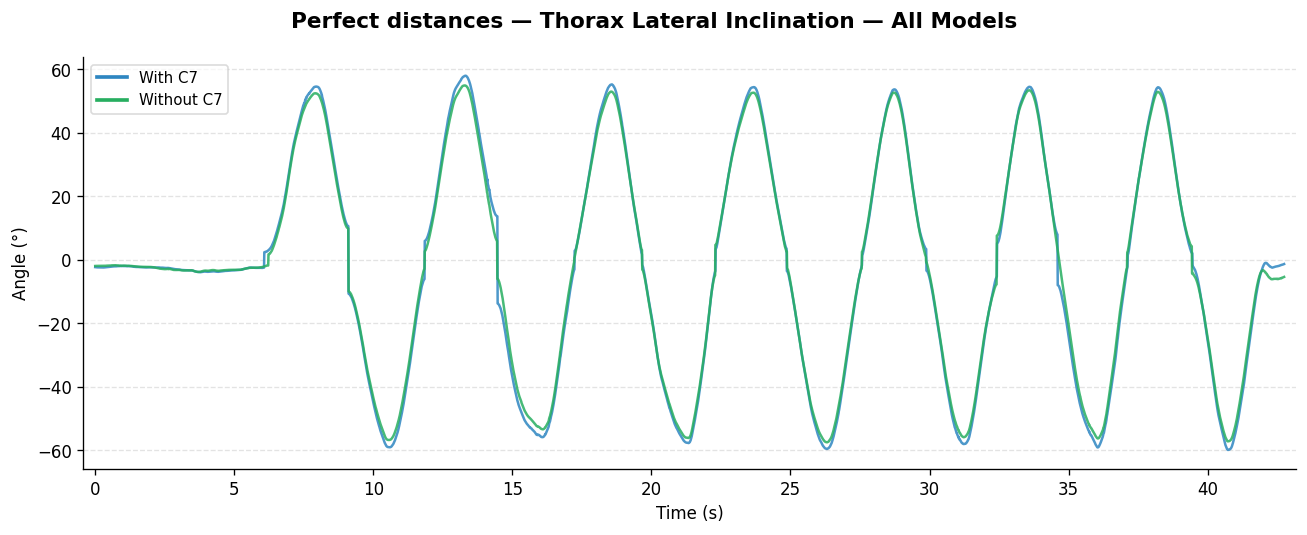

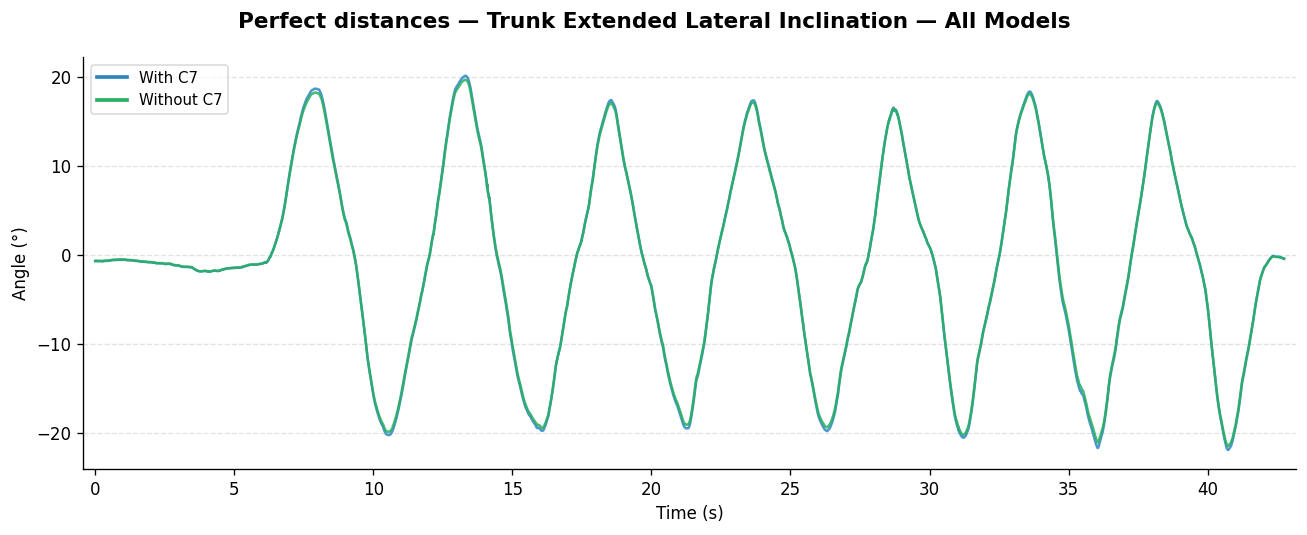

In [6]:
# ── Waveform overlay for both angle types ─────────────────────────────────────

ANGLE_CFG = [
    ("Thorax Lateral Inclination",        signals["thorax"]),
    ("Trunk Extended Lateral Inclination", signals["trunk"]),
]

for angle_name, sigs in ANGLE_CFG:
    fig, ax = plt.subplots(figsize=(11, 4.5))
    fig.suptitle(f"{SCENARIO_NAME} — {angle_name} — All Models", fontsize=13, fontweight="bold")

    legend_handles = []
    for i, (label, sig) in enumerate(sigs.items()):
        color = COLORS[i % len(COLORS)]
        ax.plot(t_s, sig, color=color, linewidth=LINE_WIDTH, alpha=ALPHA_RAW)
        legend_handles.append(mlines.Line2D([], [], color=color, linewidth=2.2, label=label))

    ax.set_xlabel("Time (s)", fontsize=10)
    ax.set_ylabel("Angle (°)", fontsize=10)
    ax.legend(handles=legend_handles, fontsize=9, framealpha=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35, zorder=0)
    ax.margins(x=0.01)
    plt.tight_layout()
    plt.show()

---
## Spike Detection — All Model Pairs

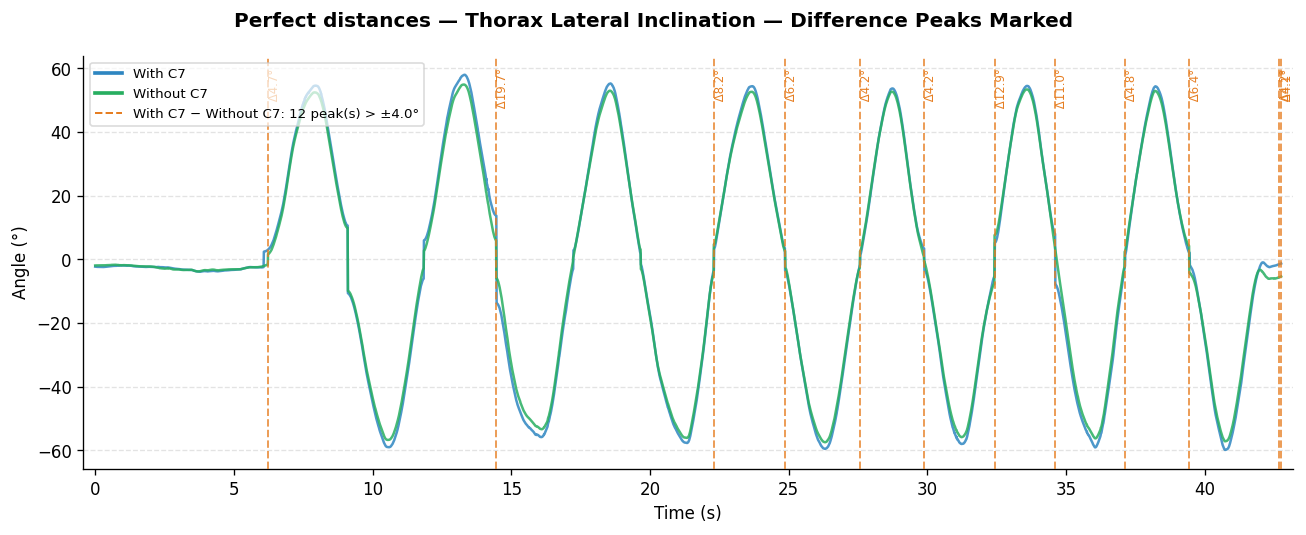


Thorax Lateral Inclination  (threshold: MAD + 2.0σ)

  With C7 − Without C7  (cutoff = 4.05°):
    t = 6.22 s  →  Δ = 4.74°
    t = 14.46 s  →  Δ = 19.73°
    t = 22.30 s  →  Δ = 8.23°
    t = 24.87 s  →  Δ = 6.15°
    t = 27.57 s  →  Δ = 4.22°
    t = 29.88 s  →  Δ = 4.20°
    t = 32.42 s  →  Δ = 12.88°
    t = 34.61 s  →  Δ = 10.96°
    t = 37.11 s  →  Δ = 4.85°
    t = 39.44 s  →  Δ = 6.43°
    t = 42.66 s  →  Δ = 4.23°
    t = 42.75 s  →  Δ = 4.06°


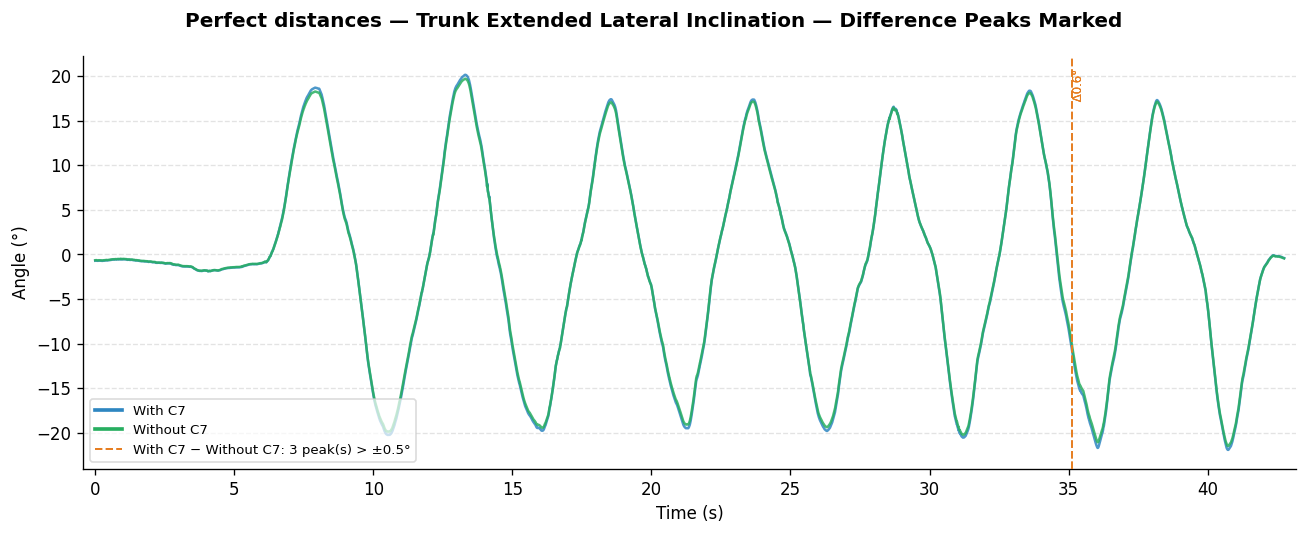


Trunk Extended Lateral Inclination  (threshold: MAD + 2.0σ)

  With C7 − Without C7  (cutoff = 0.45°):
    t = 35.12 s  →  Δ = 0.59°
    t = 35.12 s  →  Δ = 0.59°
    t = 35.12 s  →  Δ = 0.59°


In [7]:
# ── Spike detection for both angle types — With C7 vs Without C7 ──────────────

SPIKE_THRESHOLD = 2.0   # MAD + N·σ

ANGLE_CFG = [
    ("Thorax Lateral Inclination",         signals["thorax"], diffs["thorax"]),
    ("Trunk Extended Lateral Inclination",  signals["trunk"],  diffs["trunk"]),
]

diff_keys = ["diff_c7_no_c7"]

for angle_name, sigs, diff_set in ANGLE_CFG:
    spike_info = [
        (label, color, _find_spike_times(diff_set[key], t_s, SPIKE_THRESHOLD))
        for (label, color), key in zip(PAIR_INFO, diff_keys)
    ]

    fig, ax = plt.subplots(figsize=(11, 4.5))
    fig.suptitle(f"{SCENARIO_NAME} — {angle_name} — Difference Peaks Marked",
                 fontsize=12, fontweight="bold")

    legend_handles = []
    for i, (label, sig) in enumerate(sigs.items()):
        color = COLORS[i % len(COLORS)]
        ax.plot(t_s, sig, color=color, linewidth=LINE_WIDTH, alpha=ALPHA_RAW)
        legend_handles.append(mlines.Line2D([], [], color=color, linewidth=2.2, label=label))

    for label, color, (times, magnitudes, cutoff) in spike_info:
        for tk, mag in zip(times, magnitudes):
            ax.axvline(tk, color=color, linewidth=1.2, linestyle="--", alpha=0.75, zorder=4)
            ylim = ax.get_ylim()
            ax.text(tk, ylim[0] + (ylim[1] - ylim[0]) * 0.97,
                    f" Δ{mag:.1f}°", color=color, fontsize=7,
                    va="top", rotation=90, zorder=5)
        if len(times):
            legend_handles.append(
                mlines.Line2D([], [], color=color, linewidth=1.2, linestyle="--",
                              label=f"{label}: {len(times)} peak(s) > ±{cutoff:.1f}°")
            )

    ax.set_xlabel("Time (s)", fontsize=10)
    ax.set_ylabel("Angle (°)", fontsize=10)
    ax.legend(handles=legend_handles, fontsize=8, framealpha=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35, zorder=0)
    ax.locator_params(axis="y", nbins=12)
    ax.margins(x=0.01)
    plt.tight_layout()
    plt.show()

    print(f"\n{angle_name}  (threshold: MAD + {SPIKE_THRESHOLD}σ)")
    for label, _, (times, magnitudes, cutoff) in spike_info:
        print(f"\n  {label}  (cutoff = {cutoff:.2f}°):")
        if len(times) == 0:
            print("    No prominent peaks")
        for tk, mag in zip(times, magnitudes):
            print(f"    t = {tk:.2f} s  →  Δ = {mag:.2f}°")

---
## Metrics — All Model Pairs


Thorax Lateral Inclination
RMSD (°)                1.956
MAD (°)                 1.470
max_diff (°)            19.731
mean_bias (°)           -0.240
Pearson r               0.999
ICC(3,1) [95% CI]       0.998 [0.998, 0.998]
                        100.0% valid frames


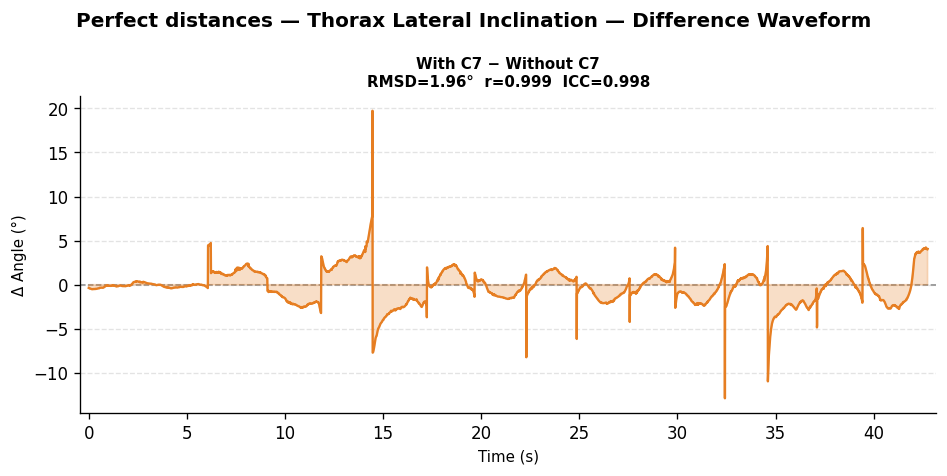


Trunk Extended Lateral Inclination
RMSD (°)                0.220
MAD (°)                 0.165
max_diff (°)            0.644
mean_bias (°)           -0.050
Pearson r               1.000
ICC(3,1) [95% CI]       1.000 [1.000, 1.000]
                        100.0% valid frames


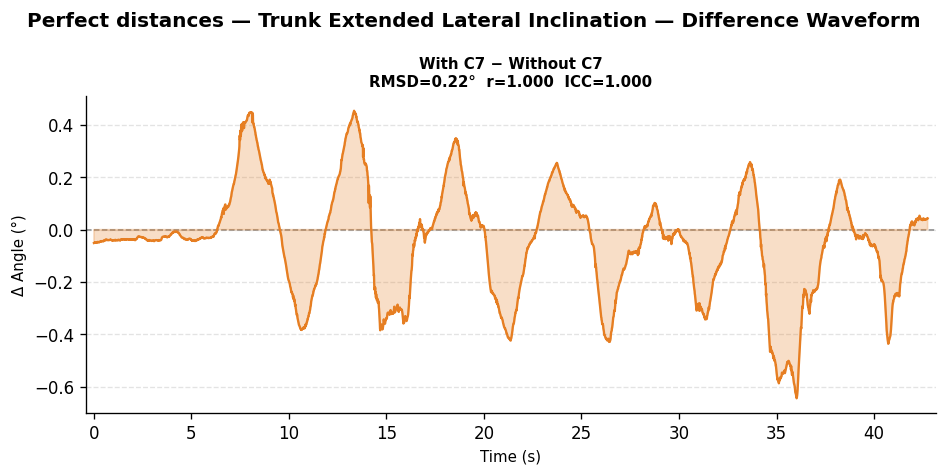

In [8]:
# ── Difference waveform + full metrics for both angle types ───────────────────

ANGLE_CFG = [
    ("Thorax Lateral Inclination",         signals["thorax"], diffs["thorax"]),
    ("Trunk Extended Lateral Inclination",  signals["trunk"],  diffs["trunk"]),
]

for angle_name, sigs, diff_set in ANGLE_CFG:
    diff = diff_set["diff_c7_no_c7"]
    label, color = PAIR_INFO[0]
    s = _stats(diff, sigs["With C7"], sigs["Without C7"])

    # ── Metrics table ─────────────────────────────────────────────────────────
    print(f"\n{'='*80}")
    print(f"{angle_name}")
    print(f"{'='*80}")
    for key, name in [
        ("RMSD",      "RMSD (°)"),
        ("MAD",       "MAD (°)"),
        ("max_diff",  "max_diff (°)"),
        ("mean_bias", "mean_bias (°)"),
        ("pearson_r", "Pearson r"),
    ]:
        print(f"{name:22s}  {s[key]:.3f}")
    print(f"{'ICC(3,1) [95% CI]':22s}  {s['icc']:.3f} [{s['icc_lo']:.3f}, {s['icc_hi']:.3f}]")
    print(f"{'':22s}  {s['pct_valid']:.1f}% valid frames")

    # ── Difference waveform plot ───────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 4))
    fig.suptitle(f"{SCENARIO_NAME} — {angle_name} — Difference Waveform",
                 fontsize=12, fontweight="bold")

    ax.axhline(0, color="gray", linewidth=0.9, linestyle="--", zorder=1)
    ax.fill_between(t_s, diff, 0, where=(diff >= 0), color=color, alpha=0.25, zorder=2)
    ax.fill_between(t_s, diff, 0, where=(diff <  0), color=color, alpha=0.25, zorder=2)
    ax.plot(t_s, diff, color=color, linewidth=1.4, zorder=3)
    ax.set_title(
        f"{label}\nRMSD={s['RMSD']:.2f}°  r={s['pearson_r']:.3f}  ICC={s['icc']:.3f}",
        fontsize=9, fontweight="bold"
    )
    ax.set_xlabel("Time (s)", fontsize=9)
    ax.set_ylabel("Δ Angle (°)", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35, zorder=0)
    ax.locator_params(axis="y", nbins=10)
    ax.margins(x=0.01)

    plt.tight_layout()
    plt.show()


---
## Virtual Marker Distances Between Models

Las grabaciones sentado **no tienen marcador físico T8** de referencia, por lo
que ya no existe un modelo "Complete". La comparación se hace **directamente
entre los modelos "With C7" y "Without C7"**: para cada marcador anatómico
(T8, C7, IJ, PX) que sea **virtual en al menos uno de los dos modelos**, se
calcula la distancia 3D (mm) entre su posición en ambos modelos, frame a
frame. Si un marcador es físico en ambos modelos se omite (no hay error de
estimación que evaluar).

| Landmark | Marcador buscado |
|---|---|
| T8 | `T8_ocst` (físico) o `T8_V` (virtual) |
| C7 | `C7_ocst` (físico) o `C7_V` (virtual) |
| IJ | `IJ_ocst` (físico) o `IJ_V` (virtual) |
| PX | `PX_ocst` (físico) o `PX_V` (virtual) |


── Bilateral ──


  IJ: physical in both models — skipped
  PX: physical in both models — skipped


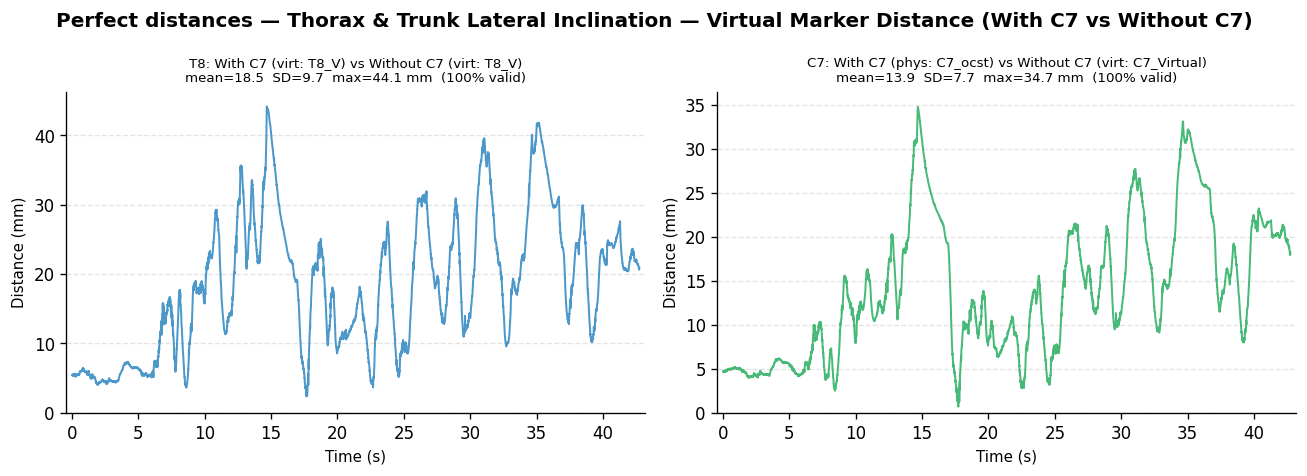

  T8: With C7 (virt: T8_V) vs Without C7 (virt: T8_V)
      mean=  18.5 mm  SD=  9.7 mm  max=  44.1 mm  valid=100.0%
  C7: With C7 (phys: C7_ocst) vs Without C7 (virt: C7_Virtual)
      mean=  13.9 mm  SD=  7.7 mm  max=  34.7 mm  valid=100.0%


In [9]:

# ── Virtual Marker Distances Between Models (With C7 vs Without C7) ──────────

def _read_positions(filepath):
    """Returns dict: label → (3, n_frames) XYZ position array in mm."""
    filepath = os.path.normpath(os.path.abspath(filepath))
    c = ezc3d.c3d(filepath)
    raw_labels = c["parameters"]["POINT"]["LABELS"]["value"]
    point_data = c["data"]["points"]
    n_labels   = min(len(raw_labels), point_data.shape[1])
    clean      = [lbl.split(":")[-1].strip() for lbl in raw_labels[:n_labels]]
    return {lbl: point_data[:3, i, :].copy() for i, lbl in enumerate(clean)}

def _find_label(mo, substr):
    """First key containing substr (case-insensitive). Returns None if not found."""
    for k in mo:
        if substr.upper() in k.upper():
            return k
    return None

def _marker_dist(pos_a, pos_b):
    """Euclidean 3D distance (mm) frame-by-frame. NaN where either marker is missing."""
    n    = min(pos_a.shape[1], pos_b.shape[1])
    a, b = pos_a[:, :n].astype(float), pos_b[:, :n].astype(float)
    dist = np.sqrt(np.sum((a - b) ** 2, axis=0))
    dist[np.any(np.isnan(a), axis=0) | np.any(np.isnan(b), axis=0)] = np.nan
    return dist

def _dist_stats(dist):
    v = dist[~np.isnan(dist)]
    if len(v) == 0:
        return None
    return {"mean": v.mean(), "std": v.std(), "max": v.max(),
            "pct": 100 * len(v) / len(dist)}

def _plot_dist_ax(ax, t, dist, title, color):
    n = min(len(t), len(dist))
    s = _dist_stats(dist)
    ax.plot(t[:n], dist[:n], color=color, linewidth=1.2, alpha=0.85)
    if s:
        ax.set_title(
            f"{title}\nmean={s['mean']:.1f}  SD={s['std']:.1f}  max={s['max']:.1f} mm  ({s['pct']:.0f}% valid)",
            fontsize=8)
    else:
        ax.set_title(f"{title}\nNo valid frames", fontsize=8)
    ax.set_xlabel("Time (s)", fontsize=9)
    ax.set_ylabel("Distance (mm)", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35, zorder=0)
    ax.set_ylim(bottom=0)
    ax.margins(x=0.01)


LANDMARKS = ["T8", "C7", "IJ", "PX"]

print("── Bilateral ──")
recs = {r["label"]: r["path"] for r in RECORDINGS}

mo_c7    = _read_positions(recs["With C7"])
mo_no_c7 = _read_positions(recs["Without C7"])

fr_mk = read_c3d(recs["With C7"])["frame_rate"]
n_mk  = min(next(iter(mo_c7.values())).shape[1],
            next(iter(mo_no_c7.values())).shape[1])
t_mk  = np.arange(n_mk) / fr_mk

# ── Locate markers and decide which comparisons make sense ────────────────────
comparisons = []  # (title, dist)
for lm in LANDMARKS:
    phys_c7    = _find_label(mo_c7,    f"{lm}_ocst")
    virt_c7    = _find_label(mo_c7,    f"{lm}_V") or _find_label(mo_c7,    f"{lm}v")
    phys_no_c7 = _find_label(mo_no_c7, f"{lm}_ocst")
    virt_no_c7 = _find_label(mo_no_c7, f"{lm}_V") or _find_label(mo_no_c7, f"{lm}v")

    key_c7,    src_c7    = (phys_c7, "phys") if phys_c7 else (virt_c7, "virt")
    key_no_c7, src_no_c7 = (phys_no_c7, "phys") if phys_no_c7 else (virt_no_c7, "virt")

    if key_c7 is None or key_no_c7 is None:
        print(f"  {lm}: not found in one of the two models — skipped")
        continue
    if src_c7 == "phys" and src_no_c7 == "phys":
        print(f"  {lm}: physical in both models — skipped")
        continue

    dist  = _marker_dist(mo_c7[key_c7][:, :n_mk], mo_no_c7[key_no_c7][:, :n_mk])
    title = f"{lm}: With C7 ({src_c7}: {key_c7}) vs Without C7 ({src_no_c7}: {key_no_c7})"
    comparisons.append((title, dist))

if not comparisons:
    print("  No virtual-marker comparisons available for this scenario.")
else:
    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, len(comparisons), figsize=(5.5 * len(comparisons), 4), squeeze=False)
    fig.suptitle(f"{SCENARIO_NAME} — Thorax & Trunk Lateral Inclination — Virtual Marker Distance (With C7 vs Without C7)",
                 fontsize=12, fontweight="bold")
    plot_colors = ["#2E86C1", "#27AE60", "#E67E22", "#8E44AD"]
    for ax, (title, dist), color in zip(axes[0], comparisons, plot_colors):
        _plot_dist_ax(ax, t_mk, dist, title, color)
    plt.tight_layout()
    plt.show()

    # ── Stats table ───────────────────────────────────────────────────────────
    for title, dist in comparisons:
        s = _dist_stats(dist)
        if s:
            print(f"  {title}\n      mean={s['mean']:6.1f} mm  SD={s['std']:5.1f} mm  max={s['max']:6.1f} mm  valid={s['pct']:.1f}%")
        else:
            print(f"  {title}\n      no valid frames")

